# Capítulo 12: Teste de hipóteses

<hr>

Códigos do livro: **Probabilidade e Estatística: Teoria, simulação e Dadados**<br>
Site: https://loja.uiclap.com/titulo/ua158988 <br>
Autor: Francisco A. Rodrigues<br>
https://sites.icmc.usp.br/francisco<br>
Universidade de São Paulo<br>
<hr>

In [1]:
# Pág. 338
import scipy.stats
alpha = 0.10
z = scipy.stats.norm.ppf(1-alpha)
print('P(Z > %1.2f) = %1.2f' % (z, alpha))

P(Z > 1.28) = 0.10


In [2]:
# Pág. 339
import scipy.stats
alpha = 0.01
n = 5
talpha = scipy.stats.t.ppf(1-alpha, n-1)
print('talpha = ', talpha)

talpha =  3.746947387979196


In [7]:
# Pág. 339
import numpy as np
from scipy import stats

# Dados observados (segundos)
x = np.array([14.4, 12.9, 15.0, 13.7, 13.5])

# H0: mu = mu0
# H1: mu > mu0
mu0 = 12.0
alpha = 0.01

# Estatísticas amostrais
n = len(x)
xbar_obs = x.mean()
s = x.std(ddof=1)

# Média amostral crítica
tcrit = stats.t.ppf(1 - alpha, n - 1)
xbar_crit = mu0 + tcrit * (s / np.sqrt(n))

print(f"Média amostral observada = {xbar_obs:.4f}")
print(f"Desvio padrão amostral = {s:.4f}")
print(f"Média amostral crítica xbar_c = {xbar_crit:.4f}")

if xbar_obs > xbar_crit:
    print("Rejeitar H0.")
else:
    print("Não rejeitar H0.")

Média amostral observada = 13.9000
Desvio padrão amostral = 0.8155
Média amostral crítica xbar_c = 13.3665
Rejeitar H0.


In [8]:
# Pág. 341
import scipy.stats
alpha = 0.05
zalpha = scipy.stats.norm.ppf(alpha)
print('zalpha = ', zalpha)

zalpha =  -1.6448536269514729


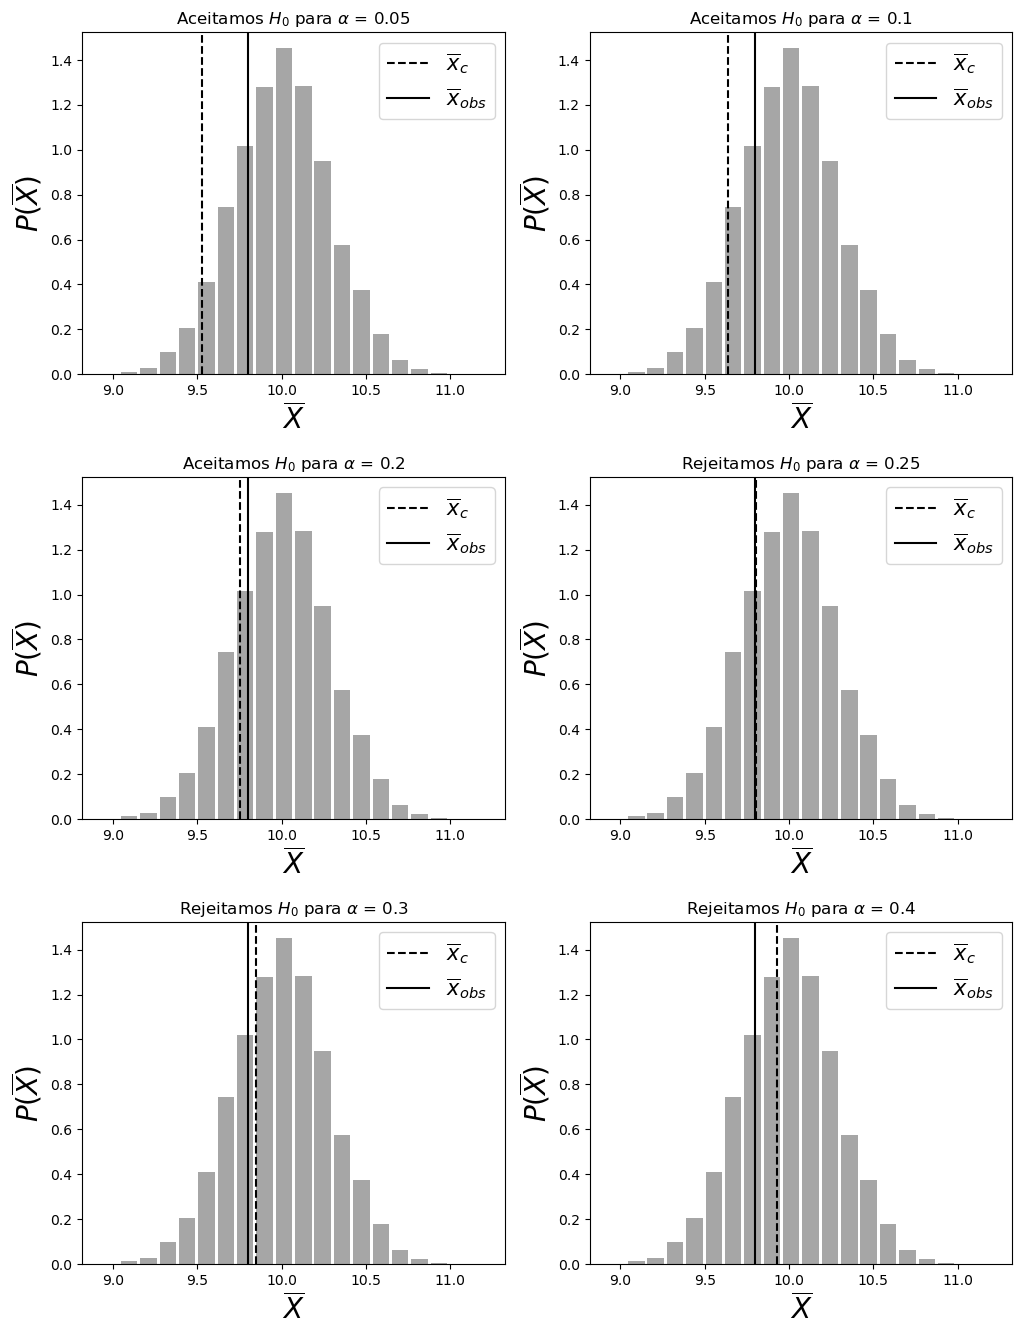

In [9]:
# Pág. 342
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)
mu = 10 # média populacional
sigma = 2 # desvio padrão
n = 50 # tamanho da amostra
xobs = 9.8 # média da amostra
Ns = 10000 # número de simulações
Xm=[] # distribuição da média amostral
for s in range(1,Ns):
    # sorteia uma amostra de tamanho n
    x = np.random.normal(mu, sigma, n) 
    Xm.append(np.mean(x))

plt.figure(figsize=(12,16))
plt.subplots_adjust(hspace=0.3)
alphas = [5,10,20,25, 30,40]
aux = 0
for alpha in alphas:
    # determina o valor crítico
    xc = np.percentile(Xm, alpha)
    plt.subplot(3, 2, aux + 1)
    aux = aux + 1
    # mostra os resultados
    plt.hist(x=Xm, bins=20, color='gray', 
             alpha=0.7, rwidth=0.85, density=True)
    plt.axvline(x=xc, color='black', 
                linestyle='--', label = r'$\overline{x}_c$')
    plt.axvline(x=xobs, color='black', 
                linestyle='-', label = r'$\overline{x}_{obs}$')
    plt.xlabel(r'$\overline{X}$', fontsize=20)
    plt.ylabel(r'$P(\overline{X})$', fontsize=20)
    plt.legend(fontsize=15)
    if(xobs < xc):
        plt.title("Rejeitamos $H_0$ para"+r' $\alpha$ = ' + 
                  str(alpha/100))
    else:
        plt.title("Aceitamos $H_0$ para"+r' $\alpha$ = ' + 
                  str(alpha/100))
plt.show(True) 

In [10]:
# Pág. 347
import numpy as np
np.random.seed(10)

mu = 100 # H0: média = 100
sigma = 20 # desvio padrão
xobs = 110 # valor observado
n = 20 # tamanho da amostra
sucesso = 0 # número de vezes que Ha é observada
ns = 1000 # número de simulações
for s in range(0,ns):
    # sorteia uma amostra de tamanho n
    x = np.random.normal(mu, sigma, n) 
    # se Ha é verificada:
    if(np.mean(x) > xobs):
        sucesso = sucesso + 1
print('valor-p', sucesso/ns)

valor-p 0.013


In [11]:
# Pág. 349
from scipy import stats
chi2 = 5.6
k = 5
pvalor = 1 - stats.chi2.cdf(chi2,k)
print('valor-p = ', pvalor)

valor-p =  0.3471050682817156


In [12]:
# Pág. 350
from scipy import stats
chi2 = 8.006
k = 3
pvalor = 1 - stats.chi2.cdf(chi2,k)
print('valor-p = ', pvalor)

valor-p =  0.045887866393100385


In [13]:
# Pág. 352
import numpy as np
import scipy.stats
# Dados
Xa = [250, 180, 200, 190, 200, 210, 250, 200, 200, 160]
Xd = [220, 190, 160, 180, 210, 180, 170, 150, 150, 140 ]

print('Média antes:', np.mean(Xa))
print('Média depois:', np.mean(Xd))
# calcula a diferença
d = 0
n = len(Xa)
for i in range(0, n):
    d = d + Xa[i]-Xd[i]
d = d/n
print('D médio:', d)
# calcula o desvio padrão amostral
sd = 0
for i in range(0,n):
    Di = Xa[i]-Xd[i]
    sd = sd + (Di-d)**2
sd = sd/(n-1)
sd = np.sqrt(sd)
print('sd:', sd)
# estatística T
mu = 0
T = (d-mu)/(sd/np.sqrt(n))
print('T:', T)
# valor-p
pvalue = scipy.stats.t.cdf(T, n-1)
print('valor-p =',1 - pvalue)

Média antes: 204.0
Média depois: 175.0
D médio: 29.0
sd: 28.06737924669451
T: 3.2673535829207565
valor-p = 0.0048618781914542275


In [14]:
# Pág. 354
import numpy as np
from scipy.stats import kstest

# dados
data = np.array([0.55, 0.35, 0.66, 0.15, 0.44, 
                 0.08,0.22, 0.93, 0.19, 0.54])
# Distribuição teórica a ser testada 
dist = 'uniform'
# Teste contra U(a,b) com a=0 e b=1
# args=(loc, scale) = (a, b-a)
stat, p = kstest(data, dist, args=(0, 1))
print(f'Estatística KS: {stat:.4f} | Valor-p: {p:.4f}')

Estatística KS: 0.2500 | Valor-p: 0.4841


In [15]:
# Pág. 354
import numpy as np
from scipy.stats import norm, kstest
np.random.seed(2011)

# gera os dados
mean = 5; std = 10
n = 100
data = np.random.normal(mean,std,n)
# define a distribuição teórica a ser testada
dist = 'norm'
# realiza o teste KS
KS = kstest(data, dist, args=(mean, std))
print('Valor-p:',KS.pvalue)

Valor-p: 0.4104775360431189


In [16]:
# Pág. 355
import numpy as np
from scipy.stats import ks_2samp
np.random.seed(2011)

# gera os dados
mean = 5; std = 10
n = 1000
data1 = np.random.normal(mean,std,n)
data2 = np.random.normal(mean,std,n)

# realiza o teste KS de duas amostras
KS = ks_2samp(data1, data2)
print('Valor-p:',KS.pvalue)

Valor-p: 0.6101664688189142


sigma (assumido) = 0.8155
tcrit = 3.7469
poder em mu=mu1=13.9000 -> 0.8497


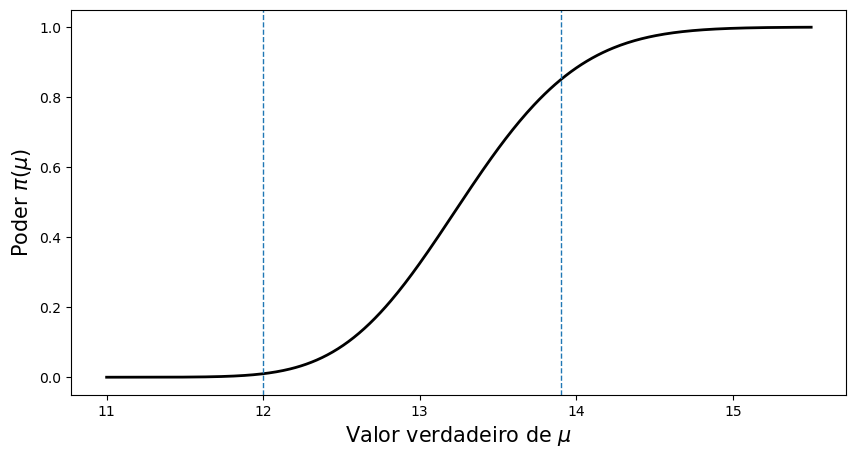

In [17]:
# Pág. 358
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# dados
x = np.array([14.4, 12.9, 15.0, 13.7, 13.5], dtype=float)
# parâmetros
mu0 = 12.0
alpha = 0.01
n = len(x)
df = n - 1
# aproximação para sigma (assumida) e mu1
sigma = x.std(ddof=1)
mu1 = x.mean()

# valor crítico do teste t unilateral à direita
tcrit = stats.t.ppf(1 - alpha, df)
# Poder em mu1 usando t não-central
delta = (mu1 - mu0) / (sigma / np.sqrt(n))
power_mu1 = 1 - stats.nct.cdf(tcrit, df, delta)
print(f"sigma (assumido) = {sigma:.4f}")
print(f"tcrit = {tcrit:.4f}")
print(f"poder em mu=mu1={mu1:.4f} -> {power_mu1:.4f}")

# Curva de poder pi(mu)
mu_vals = np.linspace(11.0, 15.5, 400)
ncp_vals = (mu_vals - mu0) / (sigma / np.sqrt(n))
power_vals = 1 - stats.nct.cdf(tcrit, df, ncp_vals)
plt.figure(figsize=(10,5))
plt.plot(mu_vals, power_vals, linewidth=2, 
         color = 'black')
plt.axvline(mu0, linestyle="--", linewidth=1)
plt.axvline(mu1, linestyle="--", linewidth=1)
plt.xlabel(r"Valor verdadeiro de $\mu$", fontsize=15)
plt.ylabel(r"Poder $\pi(\mu)$", fontsize=15)
plt.show()

In [18]:
# Pág. 364
import scipy.stats
alpha = 0.05
n = 10
talpha = scipy.stats.t.ppf(1 - alpha, n - 1)
print('talpha = ',talpha)

talpha =  1.8331129326562368


In [19]:
# Pág. 365
import scipy.stats
alpha = 0.05
n = 10
talpha = scipy.stats.t.ppf(alpha/2, n-1)
print('talpha = ',talpha)

talpha =  -2.262157162798206


In [20]:
# Pág. 366
from scipy import stats
chi2 = 10
k = 2
alpha = 1 - stats.chi2.cdf(chi2,k)
print('alpha = ', alpha)

alpha =  0.006737946999085476


In [21]:
# Pág. 366
from scipy.stats import chi2_contingency
import numpy as np

print('Tabela de contingência:')
T = np.array([[20,30,15],[20,15,30]])
print(T)
# realiza o teste chi-quadrado
stat, p, dof, E = chi2_contingency(T)
print('Graus de liberdade=%d' % dof)
print('Frequência esperada:\n', E)
print('Valor-p =', p)

Tabela de contingência:
[[20 30 15]
 [20 15 30]]
Graus de liberdade=2
Frequência esperada:
 [[20.  22.5 22.5]
 [20.  22.5 22.5]]
Valor-p = 0.006737946999085468


In [22]:
# Pág. 368
import numpy as np
import scipy.stats
# Dados
Xa = [8, 9, 7, 8, 9, 9, 7, 8]
Xd = [7, 9, 9, 8, 7, 8, 7, 8]

print('Média antes:', np.mean(Xa))
print('Média depois:', np.mean(Xd))
# calcula a diferença
d = 0
n = len(Xa)
for i in range(0, n):
    d = d + Xa[i]-Xd[i]
d = d/n
print('D médio:', d)
# calcula o desvio padrão amostral
sd = 0
for i in range(0,n):
    Di = Xa[i]-Xd[i]
    sd = sd + (Di-d)**2
sd = sd/(n-1)
sd = np.sqrt(sd)
print('sd:', sd)
# estatística T
mu = 0
T = (d-mu)/(sd/np.sqrt(n))
print('T:', T)
# valor-p
p = scipy.stats.t.cdf(T, n-1)
print('valor-p =',1 - p)

Média antes: 8.125
Média depois: 7.875
D médio: 0.25
sd: 1.164964745021435
T: 0.6069769786668839
valor-p = 0.28151390184927005


In [23]:
# Pág. 369
import numpy as np
from scipy.stats import ks_2samp
np.random.seed(100)

data1 = [0.99,-0.28,1.3,3.05,-0.47,
         -0.47,3.16,1.53,-0.94,1.09]
data2 = [0.18,0.18,0.3,0.52,0.43,
         0.29,0.61,0.14,0.29,0.37]
    
# realiza o teste KS de duas amostras
KS = ks_2samp(data1, data2)
print('Valor-p:',KS.pvalue)

Valor-p: 0.05244755244755244
